# K-Means Clustering — Iris Dataset

**Simple idea:** Group similar flowers together automatically.

The Iris dataset has 150 flowers with 4 measurements each.
K-Means will find hidden groups **without** knowing the flower species.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print('Libraries imported!')

Libraries imported!


## Step 2 — Load the Iris Dataset

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print()
df.head()

Rows: 150
Columns: 4



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Column meanings:**
- `sepal length (cm)` — length of the outer leaf of the flower
- `sepal width (cm)` — width of the outer leaf
- `petal length (cm)` — length of the inner petal
- `petal width (cm)` — width of the inner petal

## Step 3 — Explore the Data

In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Step 4 — Scale the Features

K-Means uses **distance** to group points.
Scaling makes all columns equally important.

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

print('Scaling done!')

Scaling done!


## Step 5 — Find the Best K (Elbow Method)

Try K = 1 to 10. Plot the error (inertia).
The "elbow" bend shows the best number of clusters.

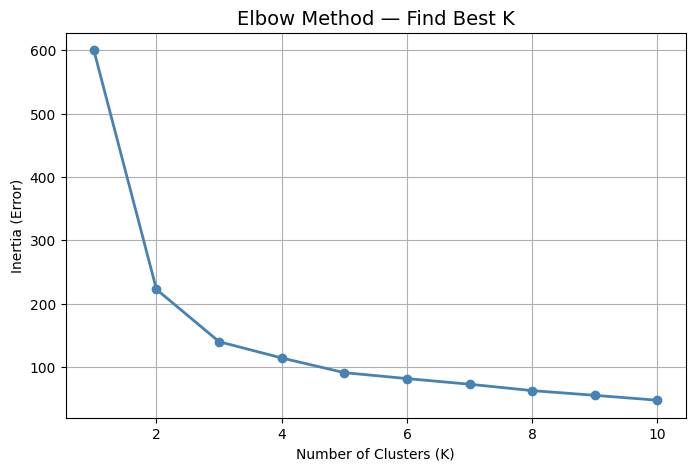

Look for the elbow bend — that is the best K!


In [5]:
inertia_list = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia_list.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_list, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Find Best K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Error)')
plt.grid(True)
plt.show()

print('Look for the elbow bend — that is the best K!')

## Step 6 — Apply K-Means with K = 3

The elbow bends at K = 3 (which also matches the 3 real flower species!).

In [6]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X)

df['Cluster'] = km.labels_

print('Cluster counts:')
print(df['Cluster'].value_counts())

Cluster counts:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


## Step 7 — Name the Groups

Look at the average values per cluster to give each group a meaningful name.

In [7]:
group_stats = df.groupby('Cluster').mean()
print(group_stats.round(2))

         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                     5.80              2.67               4.37   
1                     5.01              3.43               1.46   
2                     6.78              3.10               5.51   

         petal width (cm)  
Cluster                    
0                    1.41  
1                    0.25  
2                    1.97  


In [8]:
# Name the clusters based on petal size (the most distinct feature)
group_names = {
    df.groupby('Cluster')['petal length (cm)'].mean().idxmin(): 'Small Flowers',
    df.groupby('Cluster')['petal length (cm)'].mean().idxmax(): 'Large Flowers',
}
# The remaining cluster is Medium
for i in range(3):
    if i not in group_names:
        group_names[i] = 'Medium Flowers'

df['Group'] = df['Cluster'].map(group_names)

print('\nGroup counts:')
print(df['Group'].value_counts())


Group counts:
Group
Medium Flowers    53
Small Flowers     50
Large Flowers     47
Name: count, dtype: int64


## Step 8 — Visualise the Groups

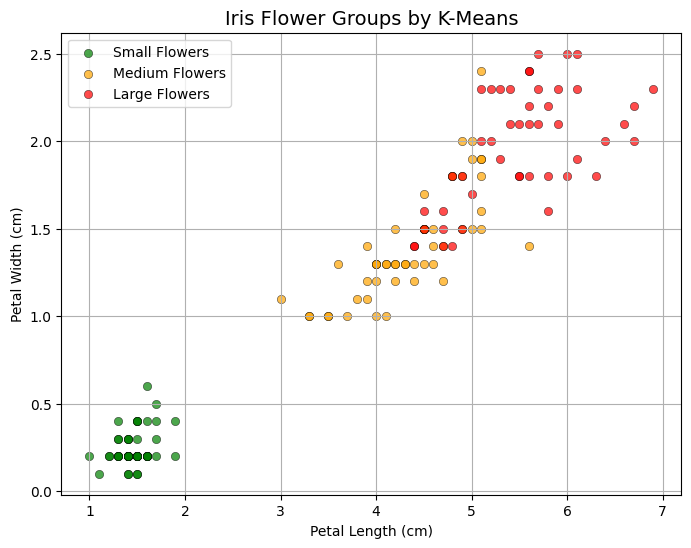

In [9]:
colors = {'Small Flowers': 'green', 'Medium Flowers': 'orange', 'Large Flowers': 'red'}

plt.figure(figsize=(8, 6))
for group, color in colors.items():
    subset = df[df['Group'] == group]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                label=group, color=color, alpha=0.7, edgecolors='black', linewidths=0.4)

plt.title('Iris Flower Groups by K-Means', fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()

## Summary

| Group | Description |
|---|---|
| **Small Flowers** | Short petals and sepals — likely Iris Setosa |
| **Medium Flowers** | Mid-range measurements — likely Iris Versicolor |
| **Large Flowers** | Long, wide petals — likely Iris Virginica |

K-Means found the 3 natural groups **without ever being told the species names!**